In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
import seaborn as sns

In [5]:
df = pd.read_csv('../data/jm1.csv')

In [6]:
df.head()

,id,loc,v(g),ev(g),iv(g),n,v,l,d,i,...,lOCode,lOComment,lOBlank,locCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,defects
0,1,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,False
1,2,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,...,1,1,1,1,1,1,1,1,1,True
2,3,72.0,7.0,1.0,6.0,198.0,1134.13,0.05,20.31,55.85,...,51,10,8,1,17,36,112,86,13,True
3,4,190.0,3.0,1.0,3.0,600.0,4348.76,0.06,17.06,254.87,...,129,29,28,2,17,135,329,271,5,True
4,5,37.0,4.0,1.0,4.0,126.0,599.12,0.06,17.19,34.86,...,28,1,6,0,11,16,76,50,7,True


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10885 entries, 0 to 10884
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 10885 non-null  int64  
 1   loc                10885 non-null  float64
 2   v(g)               10885 non-null  float64
 3   ev(g)              10885 non-null  float64
 4   iv(g)              10885 non-null  float64
 5   n                  10885 non-null  float64
 6   v                  10885 non-null  float64
 7   l                  10885 non-null  float64
 8   d                  10885 non-null  float64
 9   i                  10885 non-null  float64
 10  e                  10885 non-null  float64
 11  b                  10885 non-null  float64
 12  t                  10885 non-null  float64
 13  lOCode             10885 non-null  int64  
 14  lOComment          10885 non-null  int64  
 15  lOBlank            10885 non-null  int64  
 16  locCodeAndComment  10885 non-null

In [8]:
df.describe()

,id,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,b,t,lOCode,lOComment,lOBlank,locCodeAndComment
count,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,10885.000000,1.088500e+04,10885.000000,1.088500e+04,10885.000000,10885.000000,10885.00000,10885.000000
mean,5443.000000,42.016178,6.348590,3.401047,4.001599,114.389738,673.758017,0.135335,14.177237,29.439544,3.683637e+04,0.224766,2.046465e+03,26.252274,2.737529,4.62554,0.370785
std,3142.373174,76.593332,13.019695,6.771869,9.116889,249.502091,1938.856196,0.160538,18.709900,34.418313,4.343678e+05,0.646408,2.413154e+04,59.611201,9.008608,9.96813,1.907969
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.00000,0.000000
25%,2722.000000,11.000000,2.000000,1.000000,1.000000,14.000000,48.430000,0.030000,3.000000,11.860000,1.619400e+02,0.020000,9.000000e+00,4.000000,0.000000,0.00000,0.000000
50%,5443.000000,23.000000,3.000000,1.000000,2.000000,49.000000,217.130000,0.080000,9.090000,21.930000,2.031020e+03,0.070000,1.128300e+02,13.000000,0.000000,2.00000,0.000000
75%,8164.000000,46.000000,7.000000,3.000000,4.000000,119.000000,621.480000,0.160000,18.900000,36.780000,1.141643e+04,0.210000,6.342500e+02,28.000000,2.000000,5.00000,0.000000
max,10885.000000,3442.000000,470.000000,165.000000,402.000000,8441.000000,80843.080000,1.300000,418.200000,569.780000,3.107978e+07,26.950000,1.726655e+06,2824.000000,344.000000,447.00000,108.000000


In [9]:
df.isnull().sum()

id                   0
loc                  0
v(g)                 0
ev(g)                0
iv(g)                0
n                    0
v                    0
l                    0
d                    0
i                    0
e                    0
b                    0
t                    0
lOCode               0
lOComment            0
lOBlank              0
locCodeAndComment    0
uniq_Op              0
uniq_Opnd            0
total_Op             0
total_Opnd           0
branchCount          0
defects              0
dtype: int64

In [10]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [11]:
print(df['defects'].value_counts())
print(df['defects'].value_counts(normalize=True) * 100)

defects
False    8779
True     2106
Name: count, dtype: int64
defects
False    80.652274
True     19.347726
Name: proportion, dtype: float64


In [13]:
str_cols = ['uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount']

for col in str_cols:
    non_numeric = df[col][pd.to_numeric(df[col], errors='coerce').isna()]
    print(f"{col}: {non_numeric.value_counts().to_dict()}")

uniq_Op: {'?': 5}
uniq_Opnd: {'?': 5}
total_Op: {'?': 5}
total_Opnd: {'?': 5}
branchCount: {'?': 5}


In [14]:
mask = df[str_cols].isin(['?']).any(axis=1)
print("Affected rows:", mask.sum())
print(df[mask])

Affected rows: 5
        id   loc  v(g)  ev(g)  iv(g)      n        v     l      d      i  ...  \
143    144  49.0   4.0    3.0    3.0  185.0  1097.19  0.05  18.84  58.25  ...   
358    359  27.0   5.0    3.0    3.0   79.0   417.55  0.07  13.52  30.88  ...   
1598  1599  76.0  18.0   11.0   11.0  275.0  1650.00  0.03  34.50  47.83  ...   
4214  4215   6.0   1.0    1.0    1.0   15.0    51.89  0.34   2.92  17.79  ...   
8279  8280   9.0  13.0   10.0    4.0    0.0     0.00  0.00   0.00   0.00  ...   

      lOCode  lOComment  lOBlank  locCodeAndComment  uniq_Op  uniq_Opnd  \
143       38          0        9                  0        ?          ?   
358       19          0        6                  0        ?          ?   
1598      62          0       12                  0        ?          ?   
4214       3          0        1                  0        ?          ?   
8279       0          0        0                  0        ?          ?   

      total_Op total_Opnd branchCount defects

In [15]:
df[str_cols] = df[str_cols].replace('?', np.nan)
df[str_cols] = df[str_cols].apply(pd.to_numeric)

print(df[str_cols].dtypes)
print(df[str_cols].isnull().sum())

uniq_Op        float64
uniq_Opnd      float64
total_Op       float64
total_Opnd     float64
branchCount    float64
dtype: object
uniq_Op        5
uniq_Opnd      5
total_Op       5
total_Opnd     5
branchCount    5
dtype: int64


In [16]:
df = df.dropna()
print("Rows remaining:", len(df))

Rows remaining: 10880


In [17]:
df = df.drop(columns=['id'])
print("Columns remaining:", df.shape[1])

Columns remaining: 22


In [18]:
print("Shape:", df.shape)
print("Nulls remaining:", df.isnull().sum().sum())
print("Dtypes:\n", df.dtypes)

Shape: (10880, 22)
Nulls remaining: 0
Dtypes:
 loc                  float64
v(g)                 float64
ev(g)                float64
iv(g)                float64
n                    float64
v                    float64
l                    float64
d                    float64
i                    float64
e                    float64
b                    float64
t                    float64
lOCode                 int64
lOComment              int64
lOBlank                int64
locCodeAndComment      int64
uniq_Op              float64
uniq_Opnd            float64
total_Op             float64
total_Opnd           float64
branchCount          float64
defects                 bool
dtype: object


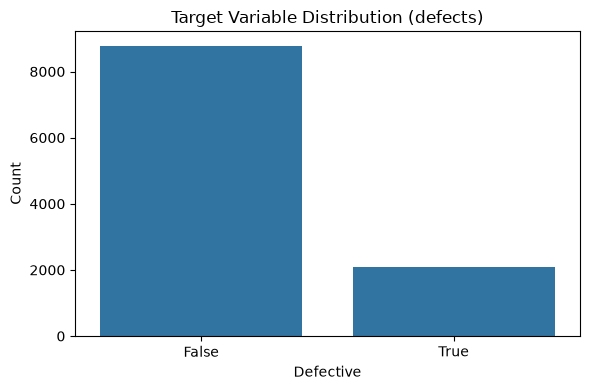

In [19]:
plt.figure(figsize=(6, 4))
sns.countplot(x='defects', data=df)
plt.title('Target Variable Distribution (defects)')
plt.xlabel('Defective')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../outputs/target_distribution.png', dpi=150)
plt.show()

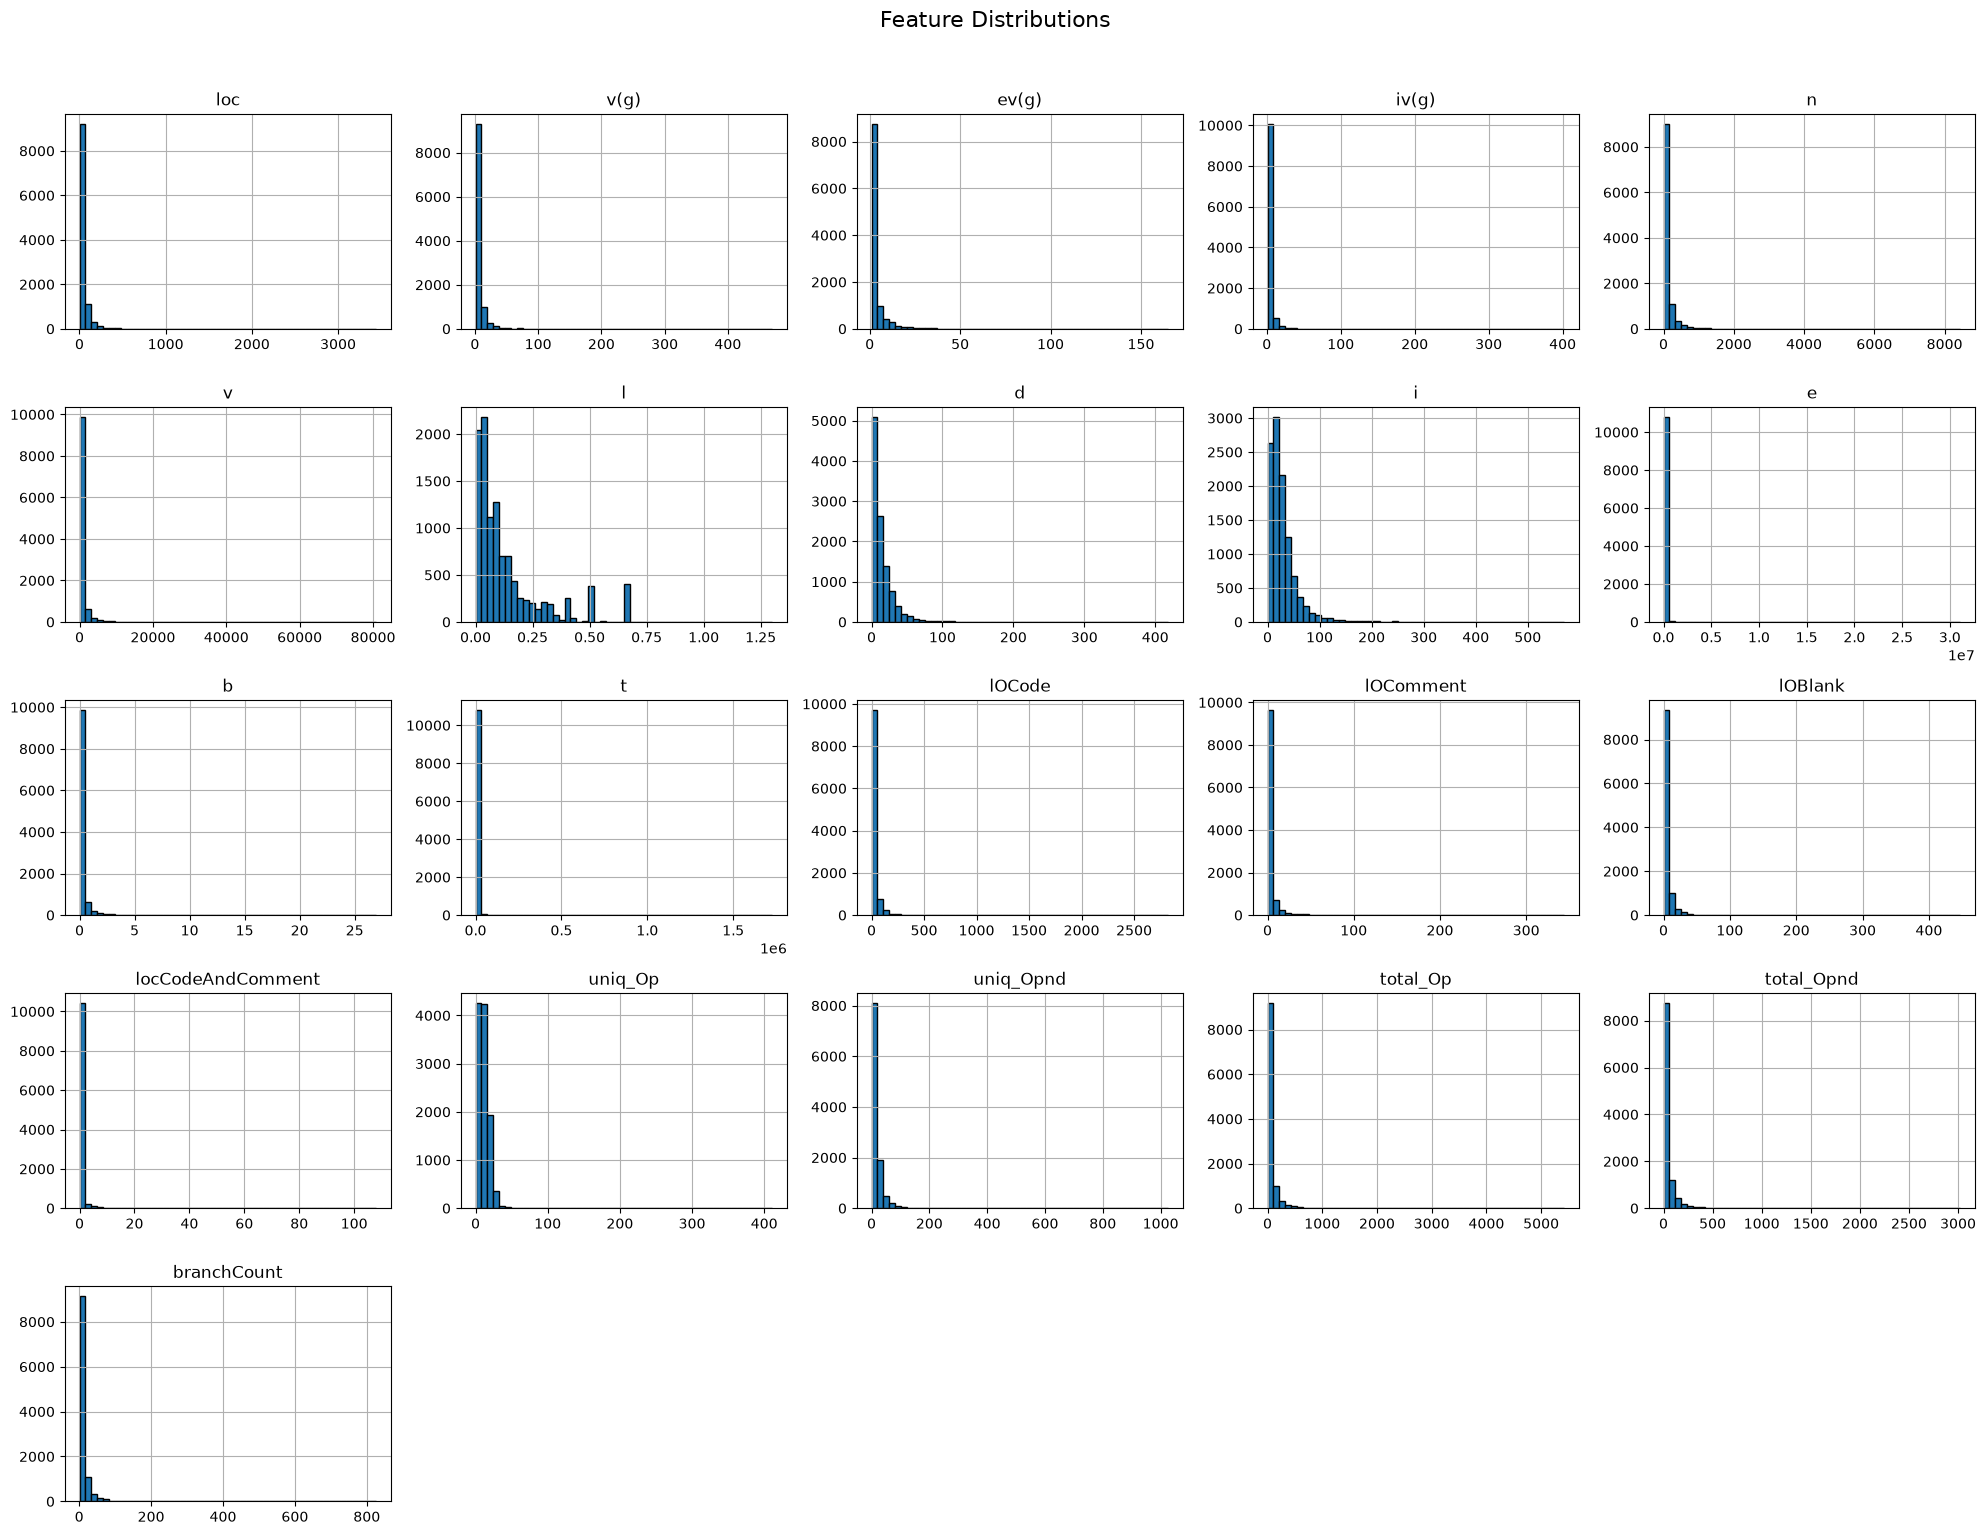

In [20]:
features = df.drop(columns=['defects'])

features.hist(figsize=(20, 15), bins=50, edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/feature_distributions.png', dpi=150)
plt.show()

IndexError: index 20 is out of bounds for axis 0 with size 20

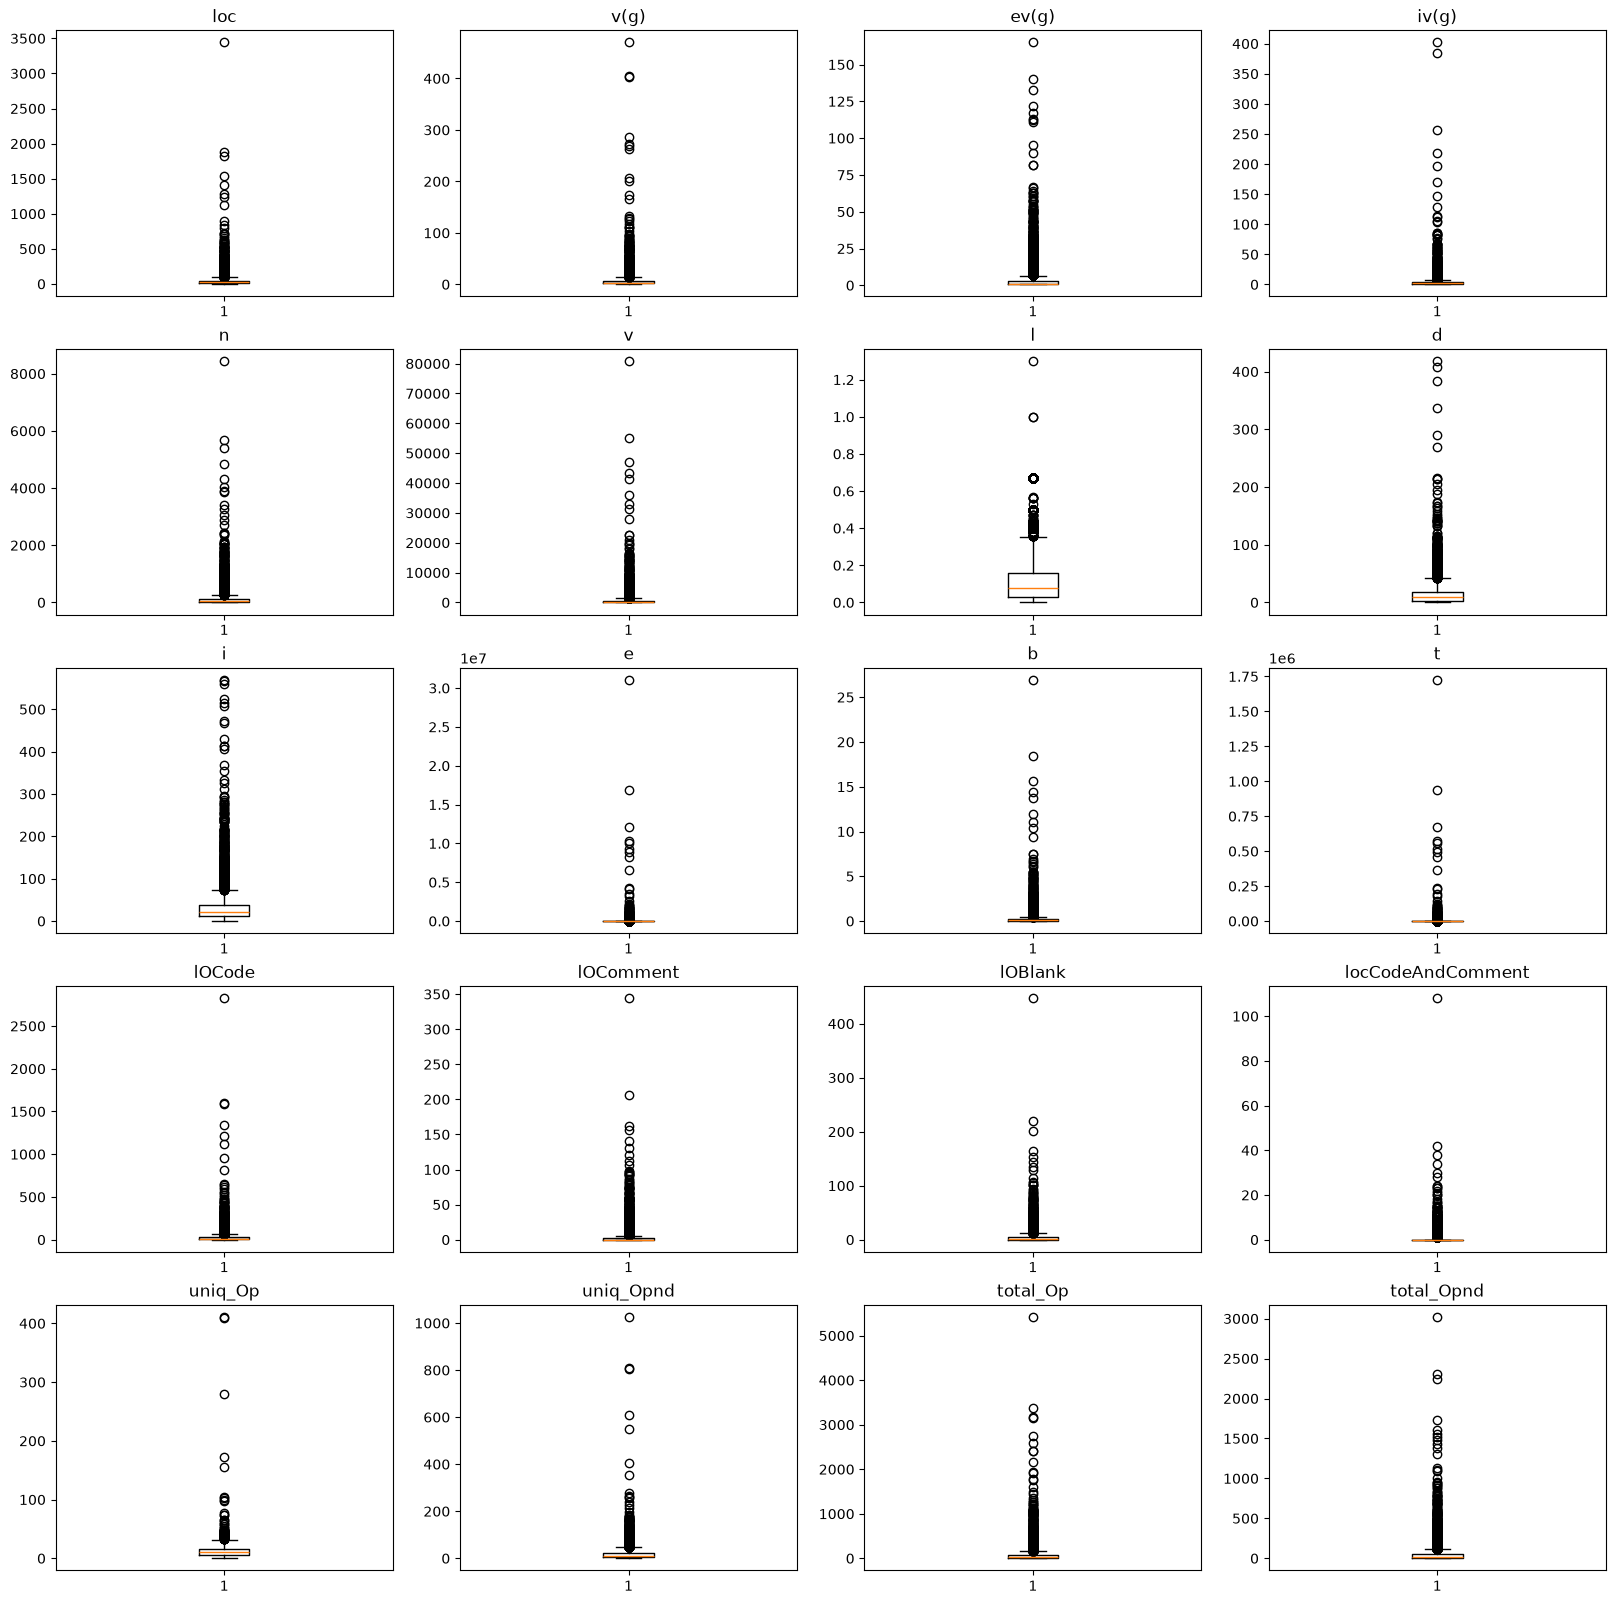

In [21]:
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(20, 20))
axes = axes.flatten()

for idx, col in enumerate(features.columns):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(col)

plt.suptitle('Boxplots for Outlier Detection', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/boxplots.png', dpi=150)
plt.show()

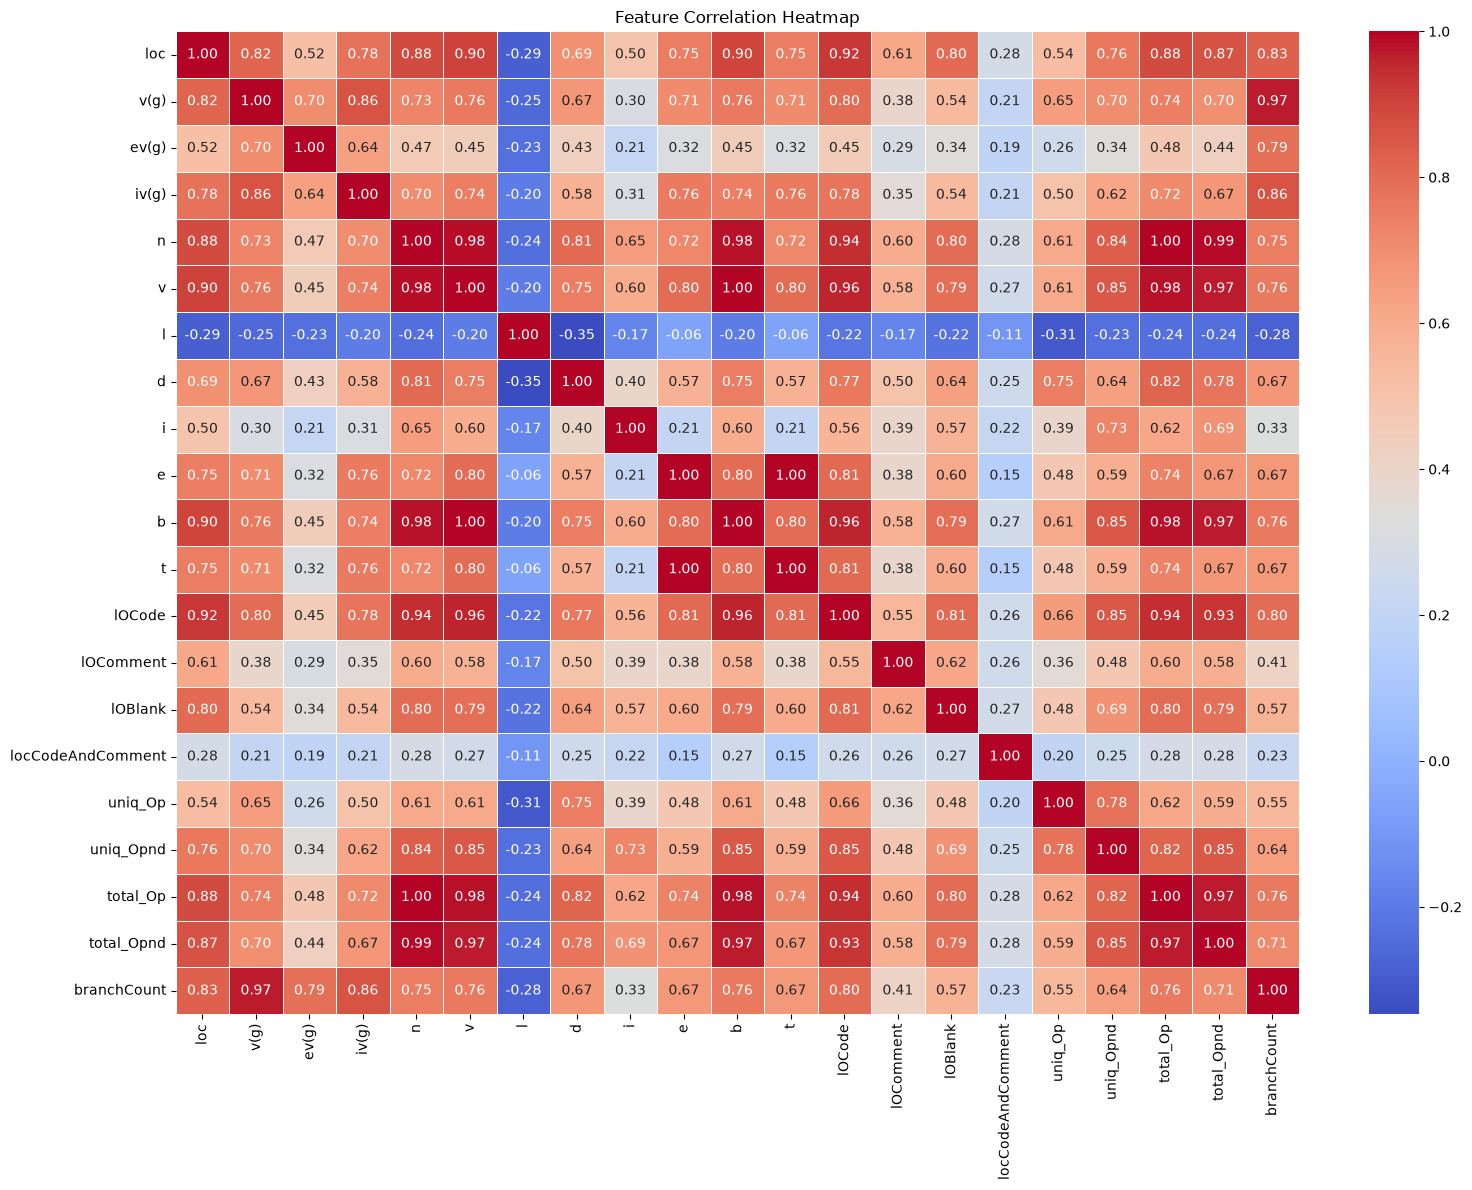

In [22]:
plt.figure(figsize=(16, 12))
corr = features.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('../outputs/correlation_heatmap.png', dpi=150)
plt.show()

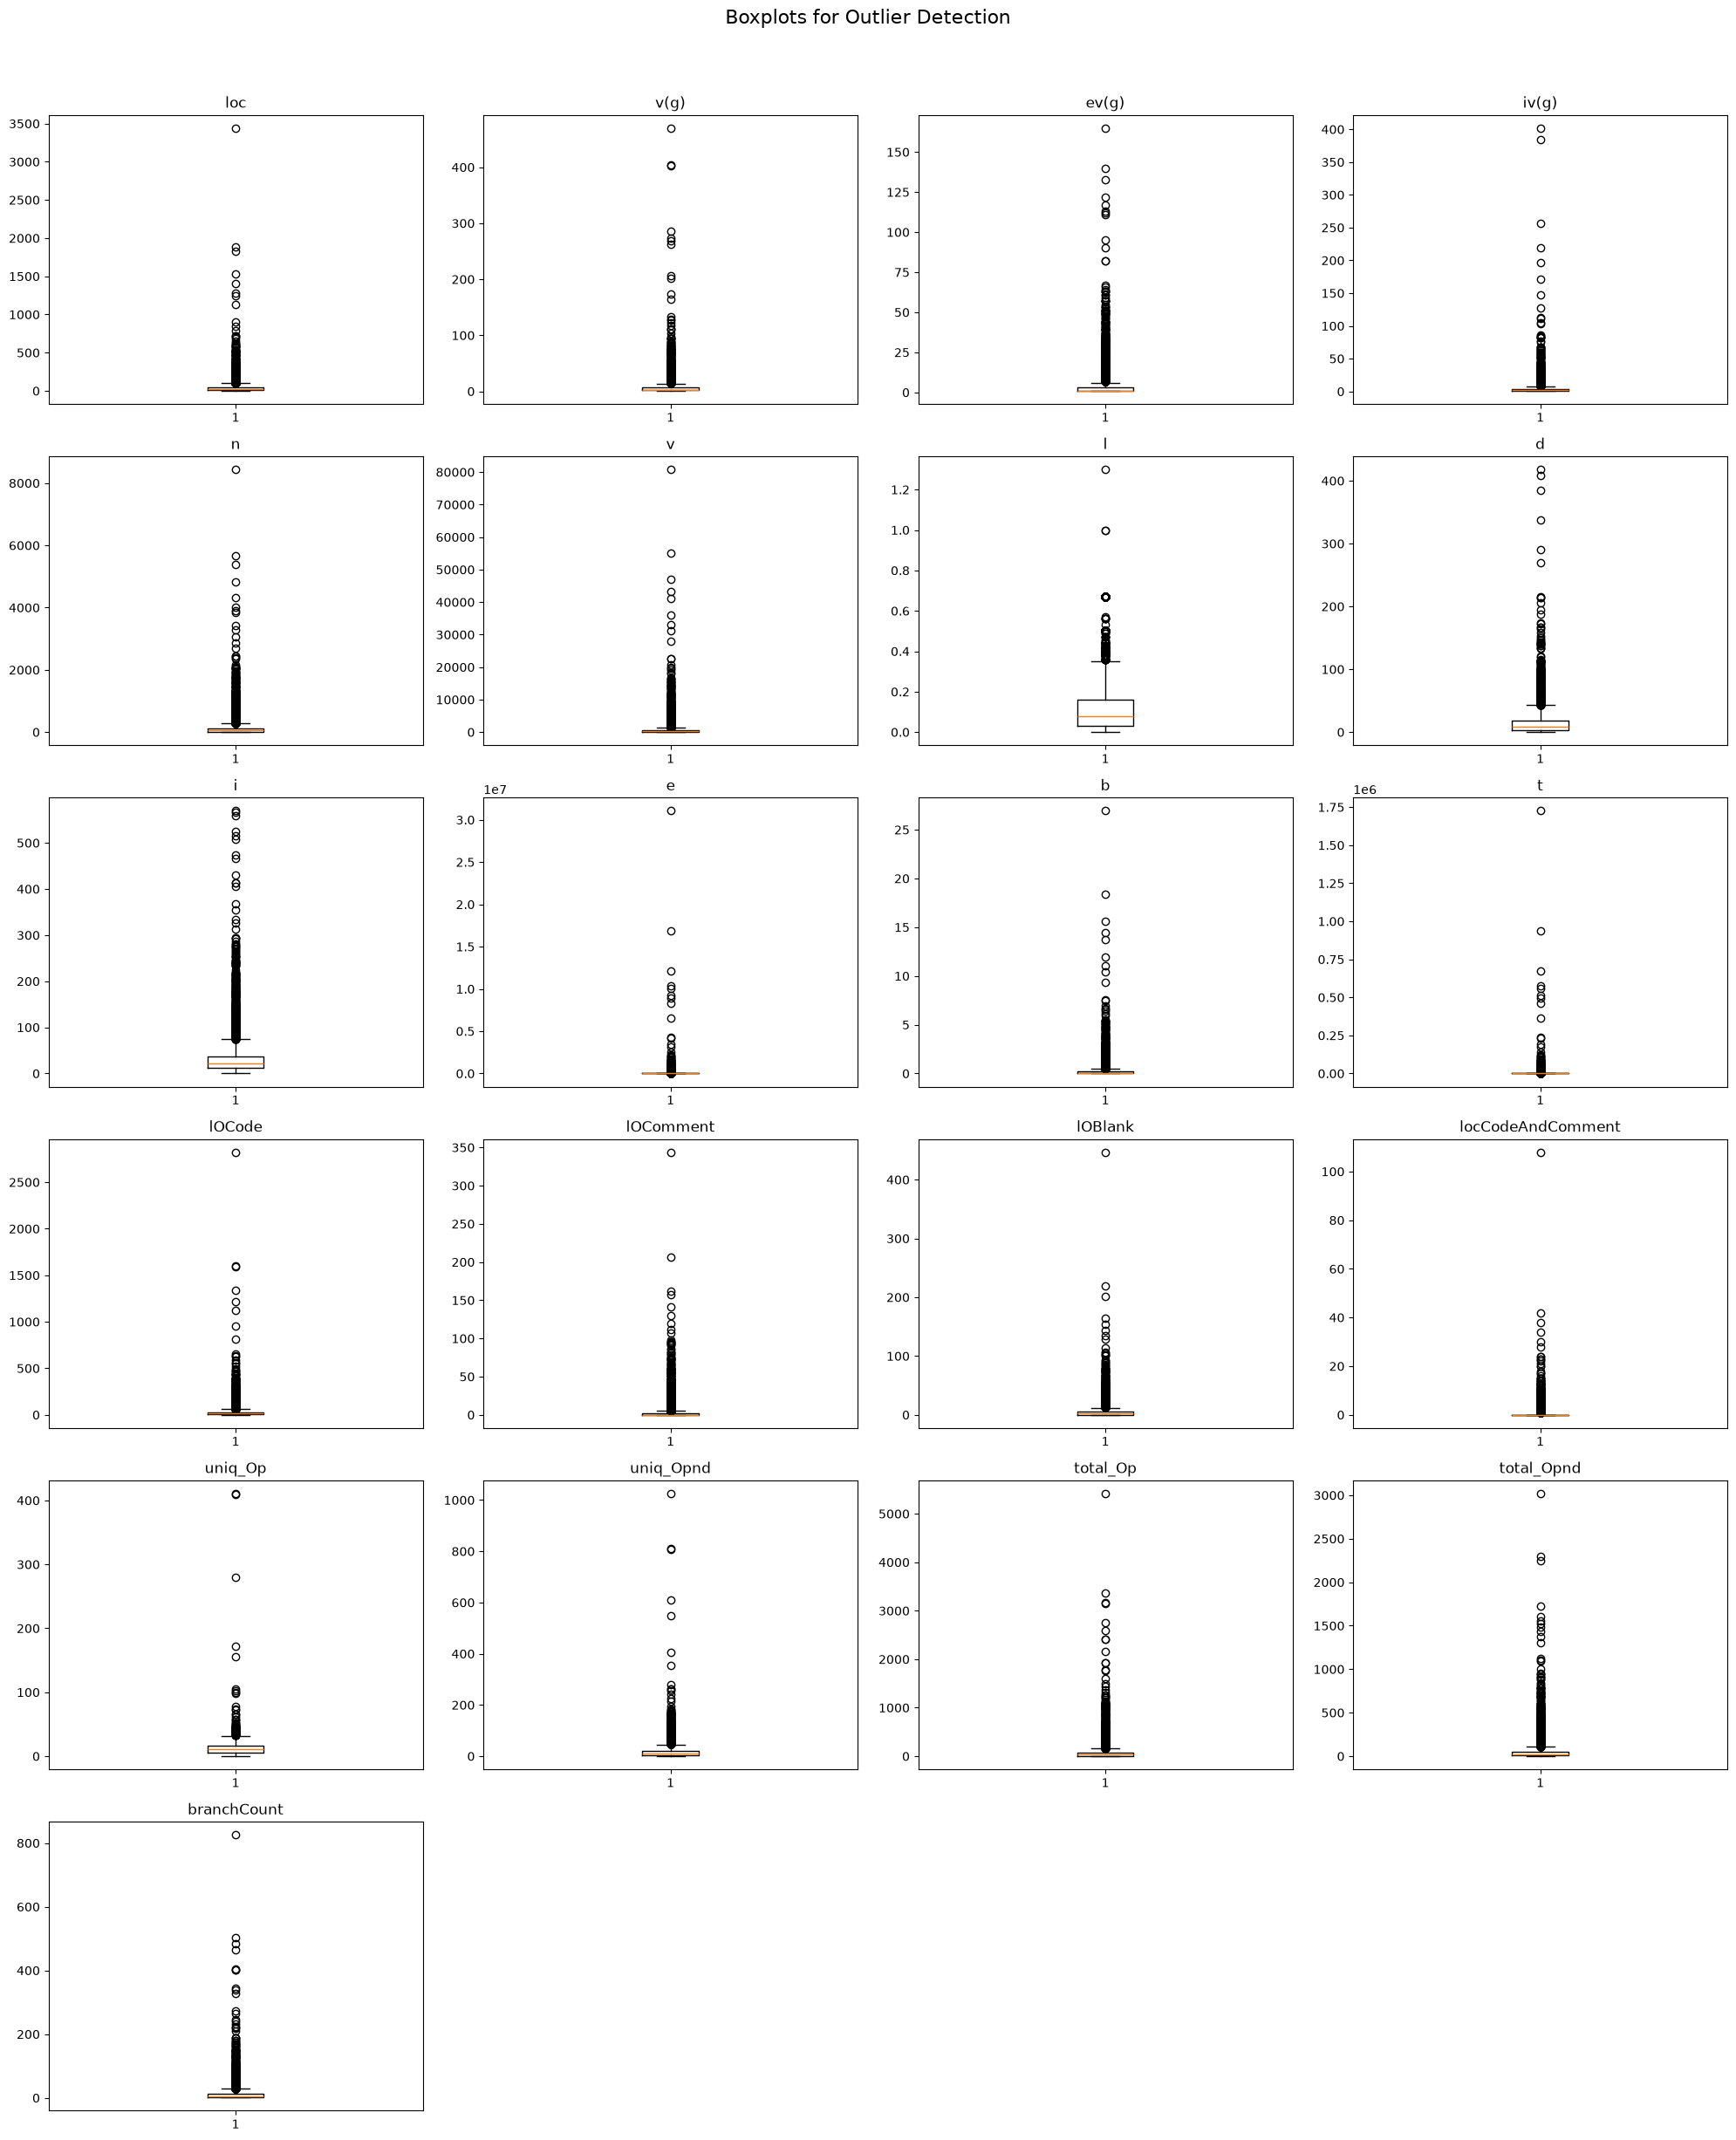

In [23]:
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(20, 24))
axes = axes.flatten()

for idx, col in enumerate(features.columns):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(col)

for idx in range(len(features.columns), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Boxplots for Outlier Detection', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/boxplots.png', dpi=150)
plt.show()

In [24]:
df['defects'] = df['defects'].astype(int)
print(df['defects'].value_counts())

defects
0    8777
1    2103
Name: count, dtype: int64


In [25]:
def cap_outliers(df, columns):
    df_capped = df.copy()
    for col in columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)
    return df_capped

feature_cols = df.drop(columns=['defects']).columns.tolist()
df_capped = cap_outliers(df, feature_cols)
print("Outlier capping done.")
print(df_capped[feature_cols].describe())

Outlier capping done.
                loc          v(g)         ev(g)         iv(g)             n  \
count  10880.000000  10880.000000  10880.000000  10880.000000  10880.000000   
mean      33.318943      4.880689      2.223934      3.045395     81.636333   
std       29.322775      4.269770      1.935008      2.405477     87.076880   
min        1.000000      1.000000      1.000000      1.000000      0.000000   
25%       11.000000      2.000000      1.000000      1.000000     14.000000   
50%       23.000000      3.000000      1.000000      2.000000     49.000000   
75%       46.000000      7.000000      3.000000      4.000000    119.000000   
max       98.500000     14.500000      6.000000      8.500000    276.500000   

                  v             l             d             i             e  \
count  10880.000000  10880.000000  10880.000000  10880.000000  10880.000000   
mean     419.079420      0.116833     12.806129     26.272385   7539.397329   
std      480.608726      0.11

In [26]:
from sklearn.model_selection import train_test_split

X = df_capped.drop(columns=['defects'])
y = df_capped['defects']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Train class distribution:\n", y_train.value_counts())
print("Test class distribution:\n", y_test.value_counts())

Train size: (8704, 21)
Test size: (2176, 21)
Train class distribution:
 defects
0    7022
1    1682
Name: count, dtype: int64
Test class distribution:
 defects
0    1755
1     421
Name: count, dtype: int64


In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling done.")
print("Train mean (should be ~0):", X_train_scaled.mean().round(4))
print("Train std (should be ~1):", X_train_scaled.std().round(4))

Scaling done.
Train mean (should be ~0): -0.0
Train std (should be ~1): 0.9759


In [28]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print("After SMOTE:")
print("Train size:", X_train_resampled.shape)
import pandas as pd
print("Class distribution:\n", pd.Series(y_train_resampled).value_counts())

After SMOTE:
Train size: (14044, 21)
Class distribution:
 defects
0    7022
1    7022
Name: count, dtype: int64


In [29]:
X_train_resampled_df = pd.DataFrame(X_train_resampled, columns=X_train.columns)
print(X_train_resampled_df['locCodeAndComment'].describe())

count    14044.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: locCodeAndComment, dtype: float64


In [30]:
X_train_resampled_df = X_train_resampled_df.drop(columns=['locCodeAndComment'])
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_train.columns)
X_test_scaled_df = X_test_scaled_df.drop(columns=['locCodeAndComment'])

print("Final train shape:", X_train_resampled_df.shape)
print("Final test shape:", X_test_scaled_df.shape)
print("Remaining features:", X_train_resampled_df.columns.tolist())

Final train shape: (14044, 20)
Final test shape: (2176, 20)
Remaining features: ['loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'l', 'd', 'i', 'e', 'b', 't', 'lOCode', 'lOComment', 'lOBlank', 'uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount']


In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr_baseline = LogisticRegression(random_state=42, max_iter=1000)
lr_baseline.fit(X_train_resampled_df, y_train_resampled)

rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train_resampled_df, y_train_resampled)

print("Baseline models trained.")

NameError: name 'X_train_resampled_df' is not defined

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

df = pd.read_csv('../data/jm1.csv')

str_cols = ['uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount']
df[str_cols] = df[str_cols].replace('?', np.nan)
df[str_cols] = df[str_cols].apply(pd.to_numeric)

df = df.dropna()
df = df.drop(columns=['id'])

df['defects'] = df['defects'].astype(int)

def cap_outliers(df, columns):
    df_capped = df.copy()
    for col in columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_capped[col] = df_capped[col].clip(lower=lower, upper=upper)
    return df_capped

feature_cols = df.drop(columns=['defects']).columns.tolist()
df_capped = cap_outliers(df, feature_cols)

df_capped = df_capped.drop(columns=['locCodeAndComment'])

X = df_capped.drop(columns=['defects'])
y = df_capped['defects']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

X_train_resampled_df = pd.DataFrame(X_train_resampled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_train.columns)

print("Pipeline complete.")
print("Train shape:", X_train_resampled_df.shape)
print("Test shape:", X_test_scaled_df.shape)

Pipeline complete.
Train shape: (14044, 20)
Test shape: (2176, 20)


In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr_baseline = LogisticRegression(random_state=42, max_iter=1000)
lr_baseline.fit(X_train_resampled_df, y_train_resampled)

rf_baseline = RandomForestClassifier(random_state=42)
rf_baseline.fit(X_train_resampled_df, y_train_resampled)

print("Baseline models trained.")

Baseline models trained.


In [4]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['Non-Defective', 'Defective']))
    print("ROC-AUC Score:", roc_auc_score(y_test, y_prob).round(4))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

evaluate_model("Logistic Regression (Baseline)", lr_baseline, X_test_scaled_df, y_test)
evaluate_model("Random Forest (Baseline)", rf_baseline, X_test_scaled_df, y_test)


Model: Logistic Regression (Baseline)
               precision    recall  f1-score   support

Non-Defective       0.88      0.75      0.81      1755
    Defective       0.36      0.59      0.45       421

     accuracy                           0.72      2176
    macro avg       0.62      0.67      0.63      2176
 weighted avg       0.78      0.72      0.74      2176



AttributeError: 'float' object has no attribute 'round'

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def evaluate_model(name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")
    print(classification_report(y_test, y_pred, target_names=['Non-Defective', 'Defective']))
    print("ROC-AUC Score:", round(roc_auc_score(y_test, y_prob), 4))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

evaluate_model("Logistic Regression (Baseline)", lr_baseline, X_test_scaled_df, y_test)
evaluate_model("Random Forest (Baseline)", rf_baseline, X_test_scaled_df, y_test)


Model: Logistic Regression (Baseline)
               precision    recall  f1-score   support

Non-Defective       0.88      0.75      0.81      1755
    Defective       0.36      0.59      0.45       421

     accuracy                           0.72      2176
    macro avg       0.62      0.67      0.63      2176
 weighted avg       0.78      0.72      0.74      2176

ROC-AUC Score: 0.7199
Confusion Matrix:
[[1313  442]
 [ 172  249]]

Model: Random Forest (Baseline)
               precision    recall  f1-score   support

Non-Defective       0.85      0.89      0.87      1755
    Defective       0.43      0.35      0.39       421

     accuracy                           0.78      2176
    macro avg       0.64      0.62      0.63      2176
 weighted avg       0.77      0.78      0.78      2176

ROC-AUC Score: 0.749
Confusion Matrix:
[[1561  194]
 [ 274  147]]


In [6]:
from sklearn.model_selection import cross_val_score
import numpy as np

for name, model in [("Logistic Regression", lr_baseline), ("Random Forest", rf_baseline)]:
    scores = cross_val_score(model, X_train_resampled_df, y_train_resampled, 
                             cv=5, scoring='f1')
    print(f"{name} — 5-Fold CV F1: {scores.round(4)} | Mean: {scores.mean().round(4)} | Std: {scores.std().round(4)}")

Logistic Regression — 5-Fold CV F1: [0.6235 0.6292 0.6245 0.6294 0.6251] | Mean: 0.6264 | Std: 0.0025
Random Forest — 5-Fold CV F1: [0.7395 0.8848 0.9158 0.925  0.9171] | Mean: 0.8764 | Std: 0.0698


In [7]:
from sklearn.model_selection import GridSearchCV

lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['lbfgs', 'liblinear'],
    'class_weight': [None, 'balanced']
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, max_iter=1000),
    lr_params, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
lr_grid.fit(X_train_resampled_df, y_train_resampled)
print("Best LR params:", lr_grid.best_params_)
print("Best LR CV F1:", round(lr_grid.best_score_, 4))

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best LR params: {'C': 0.01, 'class_weight': None, 'solver': 'liblinear'}
Best LR CV F1: 0.63


In [8]:
rf_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'class_weight': [None, 'balanced']
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, cv=5, scoring='f1', n_jobs=-1, verbose=1
)
rf_grid.fit(X_train_resampled_df, y_train_resampled)
print("Best RF params:", rf_grid.best_params_)
print("Best RF CV F1:", round(rf_grid.best_score_, 4))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best RF params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Best RF CV F1: 0.879


In [9]:
lr_tuned = lr_grid.best_estimator_
rf_tuned = rf_grid.best_estimator_

# Evaluate
evaluate_model("Logistic Regression (Tuned)", lr_tuned, X_test_scaled_df, y_test)
evaluate_model("Random Forest (Tuned)", rf_tuned, X_test_scaled_df, y_test)


Model: Logistic Regression (Tuned)
               precision    recall  f1-score   support

Non-Defective       0.89      0.74      0.81      1755
    Defective       0.36      0.60      0.45       421

     accuracy                           0.71      2176
    macro avg       0.62      0.67      0.63      2176
 weighted avg       0.78      0.71      0.74      2176

ROC-AUC Score: 0.7195
Confusion Matrix:
[[1302  453]
 [ 168  253]]

Model: Random Forest (Tuned)
               precision    recall  f1-score   support

Non-Defective       0.85      0.89      0.87      1755
    Defective       0.44      0.36      0.40       421

     accuracy                           0.79      2176
    macro avg       0.65      0.63      0.64      2176
 weighted avg       0.77      0.79      0.78      2176

ROC-AUC Score: 0.7446
Confusion Matrix:
[[1565  190]
 [ 269  152]]


In [10]:
for name, model in [("Logistic Regression (Tuned)", lr_tuned), ("Random Forest (Tuned)", rf_tuned)]:
    scores = cross_val_score(model, X_train_resampled_df, y_train_resampled,
                             cv=5, scoring='f1', n_jobs=-1)
    print(f"{name} — 5-Fold CV F1: {scores.round(4)} | Mean: {scores.mean().round(4)} | Std: {scores.std().round(4)}")

Logistic Regression (Tuned) — 5-Fold CV F1: [0.6276 0.6253 0.6295 0.6354 0.632 ] | Mean: 0.63 | Std: 0.0035
Random Forest (Tuned) — 5-Fold CV F1: [0.7491 0.8857 0.9195 0.9243 0.9164] | Mean: 0.879 | Std: 0.0664


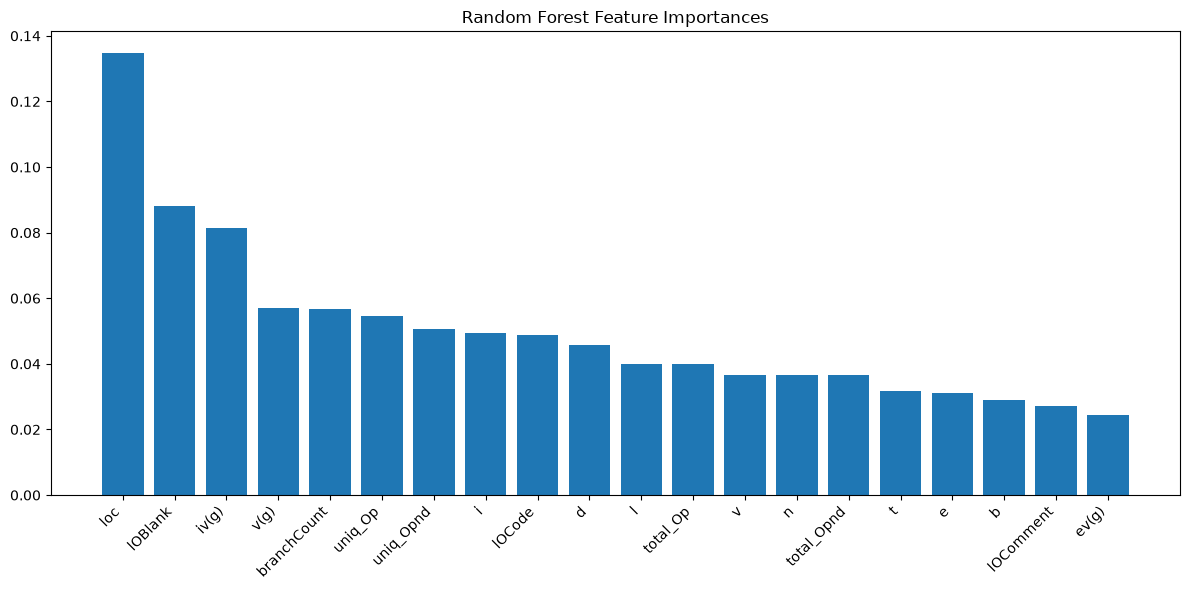

In [11]:
import matplotlib.pyplot as plt

importances = rf_tuned.feature_importances_
feature_names = X_train_resampled_df.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(12, 6))
plt.bar(range(20), importances[indices])
plt.xticks(range(20), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.savefig('../outputs/feature_importance.png', dpi=150)
plt.show()